In [86]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from skimage.feature import graycomatrix, graycoprops
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
from scipy import stats
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.base import clone
from scipy.stats import skew, kurtosis
import tempfile

Подсчет гистограммы:

In [2]:
def calculate_histograms(image_paths):
    results = {}
    
    for i, img_path in enumerate(image_paths, 1):
        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is None:
                print(f"не удалось загрузить изображение {img_path}")
                continue
            
            hist = cv2.calcHist([img], [0], None, [256], [0, 256])
            
            hist_flat = hist.flatten()
            total_pixels = img.shape[0] * img.shape[1]
            
            prob = hist_flat / total_pixels
            
            # средняя яркость
            intensities = np.arange(256)
            mean_intensity = np.sum(intensities * prob)
            
            # отклонение
            variance = np.sum(((intensities - mean_intensity) ** 2) * prob)
            std_intensity = np.sqrt(variance)
            
            # асимметрия
            if std_intensity > 0:
                skewness = np.sum(((intensities - mean_intensity) ** 3) * prob) / (std_intensity ** 3)
            else:
                skewness = 0
            
            # эксцесс
            if std_intensity > 0:
                kurt = np.sum(((intensities - mean_intensity) ** 4) * prob) / (std_intensity ** 4) - 3
            else:
                kurt = 0
            
            # яркость
            non_zero = np.where(hist_flat > 0)[0]
            min_intensity = non_zero[0] if len(non_zero) > 0 else 0
            max_intensity = non_zero[-1] if len(non_zero) > 0 else 0
            
            dominant_intensity = np.argmax(hist_flat)
            
            # энтропия
            prob_nonzero = prob[prob > 0]
            entropy = -np.sum(prob_nonzero * np.log2(prob_nonzero))
            
            # контраст
            contrast = max_intensity - min_intensity
            
            results[f"image_{i}"] = {
                'histogram': hist,
                'image': img,
                'shape': img.shape,
                'total_pixels': total_pixels,
                'mean': mean_intensity,
                'std': std_intensity,
                'skewness': skewness,
                'kurtosis': kurt,
                'entropy': entropy,
                'min': min_intensity,
                'max': max_intensity,
                'dominant_intensity': dominant_intensity,
                'contrast': contrast
            }
            
        except Exception as e:
            print(f"Ошибка при обработке {img_path}: {e}")
            continue
    
    return results

In [3]:
def visualize_histograms(results):
    n_images = len(results)
    
    if n_images == 0:
        print("Нет данных для визуализации")
        return
    
    fig, axes = plt.subplots(n_images, 3, figsize=(15, 4 * n_images))

    if n_images == 1:
        axes = axes.reshape(1, -1)
    img_name = ["aluminium_foil", "brown_bread", "corduroy"]
    for i, (key, data) in enumerate(results.items()):
        axes[i, 0].imshow(data['image'], cmap='gray', vmin=0, vmax=255)
        axes[i, 0].set_title(img_name[i])
        axes[i, 0].axis('off')
        
        hist = data['histogram'].flatten()
        axes[i, 1].bar(range(256), hist, width=1.0, color='blue', alpha=0.7)
        axes[i, 1].set_xlabel("Уровень яркости (0-255)")
        axes[i, 1].set_ylabel("Количество пикселей")
        axes[i, 1].set_xlim(0, 255)
        axes[i, 1].grid(True, alpha=0.3)
        
        axes[i, 2].axis('off')

        stats_text = (
            f"mean: {data['mean']:.2f}\n"
            f"std: {data['std']:.2f}\n"
            f"skewness: {data['skewness']:.3f}\n"
            f"kurtosis: {data['kurtosis']:.3f}\n"
            f"entropy: {data['entropy']:.4f}\n"
            f"min: {data['min']}\n"
            f"max: {data['max']}"
        )
        
        axes[i, 2].text(0.5, 0.5, stats_text, 
                         fontsize=12, fontfamily='monospace',
                         ha='center', va='center',
                         transform=axes[i, 2].transAxes)
    
    plt.tight_layout()
    plt.show()

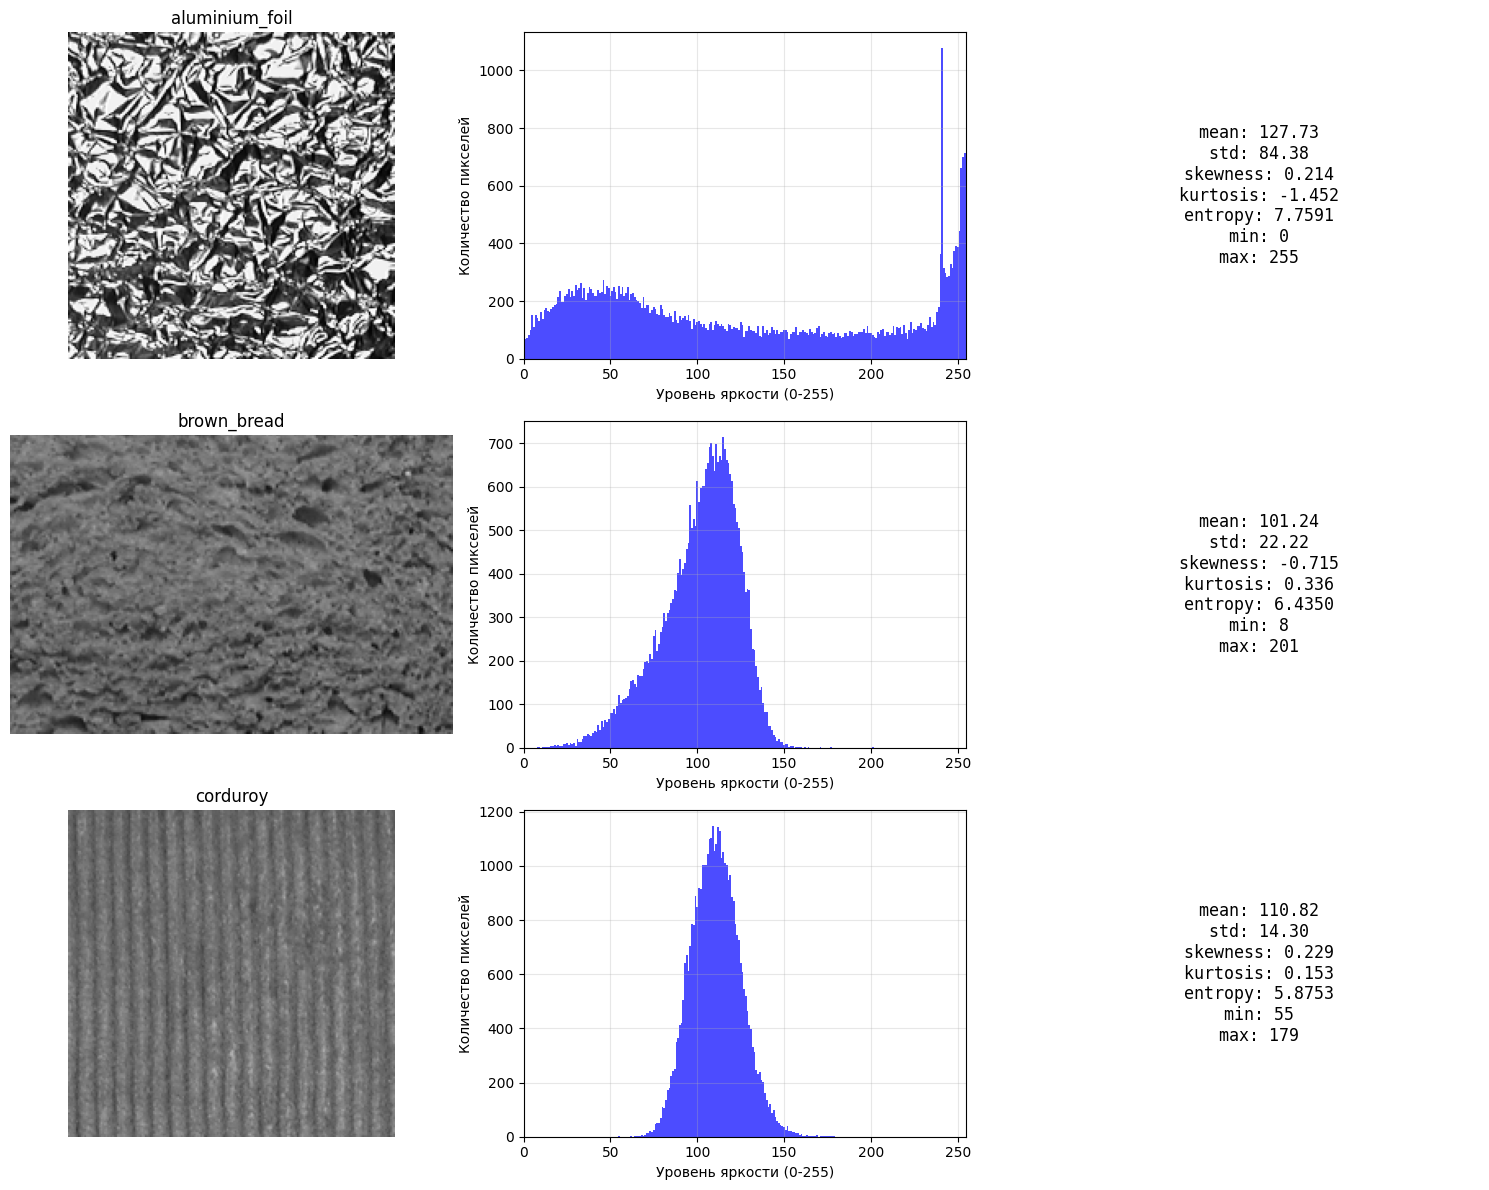

In [26]:
# берем изображения первых 3 текстур в дирректории
image_paths = [
    "./kth_tips_grey_200x200/KTH_TIPS/aluminium_foil/15-scale_7_im_1_grey.png",
    "./kth_tips_grey_200x200/KTH_TIPS/brown_bread/48-scale_7_im_1_grey.png",
    "./kth_tips_grey_200x200/KTH_TIPS/corduroy/42-scale_7_im_1_grey.png"
]

for path in image_paths:
    if not os.path.exists(path):
        print(f"Внимание: файл не найден - {path}")

results = calculate_histograms(image_paths)

if results:
    visualize_histograms(results)

Рассчет текстурных характеристик Laws:

In [52]:
def calculate_laws_texture_energy(image):
    L5 = np.array([1, 4, 6, 4, 1])
    E5 = np.array([-1, -2, 0, 2, 1])
    S5 = np.array([-1, 0, 2, 0, -1])
    R5 = np.array([1, -4, 6, -4, 1])
    
    L5 = L5 / np.sum(np.abs(L5))
    E5 = E5 / np.sum(np.abs(E5))
    S5 = S5 / np.sum(np.abs(S5))
    R5 = R5 / np.sum(np.abs(R5))
    
    filters = [L5, E5, S5, R5]
    names = ['L5', 'E5', 'S5', 'R5']
    
    g = {}
    
    for i in range(4):
        for j in range(4):
            mask = np.outer(filters[i], filters[j])
            filtered = cv2.filter2D(image.astype(np.float32), -1, mask)
            g[f"{names[i]}{names[j]}"] = filtered
    
    P = 15
    Q = 15
    
    h = {}
    for name, filtered in g.items():
        h[name] = cv2.blur(np.abs(filtered), (2*P+1, 2*Q+1))
    
    h1 = h['E5E5']
    h2 = h['S5S5']
    h3 = h['R5R5']
    h4 = (h['L5E5'] + h['E5L5']) / 2
    h5 = (h['L5S5'] + h['S5L5']) / 2
    h6 = (h['L5R5'] + h['R5L5']) / 2
    h7 = (h['E5S5'] + h['S5E5']) / 2
    h8 = (h['E5R5'] + h['R5E5']) / 2
    h9 = (h['S5R5'] + h['R5S5']) / 2
    
    energy_maps = [h1, h2, h3, h4, h5, h6, h7, h8, h9]
    map_names = ['E5E5', 'S5S5', 'R5R5', 'L5E5/E5L5', 'L5S5/S5L5', 'L5R5/R5L5', 
                 'E5S5/S5E5', 'E5R5/R5E5', 'S5R5/R5S5']
    
    features = {}
    for name, energy_map in zip(map_names, energy_maps):
        features[name] = np.mean(energy_map)
    
    return features

In [63]:
def visualize_with_features(image_paths):
    n_images = len(image_paths)
    
    fig, axes = plt.subplots(n_images, 2, figsize=(14, 4 * n_images), 
                            gridspec_kw={'width_ratios': [1, 0.8]})
    
    if n_images == 1:
        axes = axes.reshape(1, -1)
    
    for idx, img_path in enumerate(image_paths):
        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is None:
                continue
            
            class_name = os.path.basename(os.path.dirname(img_path))
            
            features = calculate_laws_texture_energy(img)
            
            axes[idx, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
            axes[idx, 0].set_title(f"{class_name}", fontsize=14)
            axes[idx, 0].axis('off')
            
            axes[idx, 1].axis('off')
            
            stats_text = "Laws Features:\n\n"
            for name, value in features.items():
                formatted_value = f"{value:.3f}"
                stats_text += f"{name}: {formatted_value}\n"
            
            axes[idx, 1].text(0.1, 0.95, stats_text, 
                             fontsize=11, fontfamily='monospace',
                             verticalalignment='top',
                             linespacing=1.5)
                             
        except Exception:
            continue
    
    plt.tight_layout()
    plt.show()

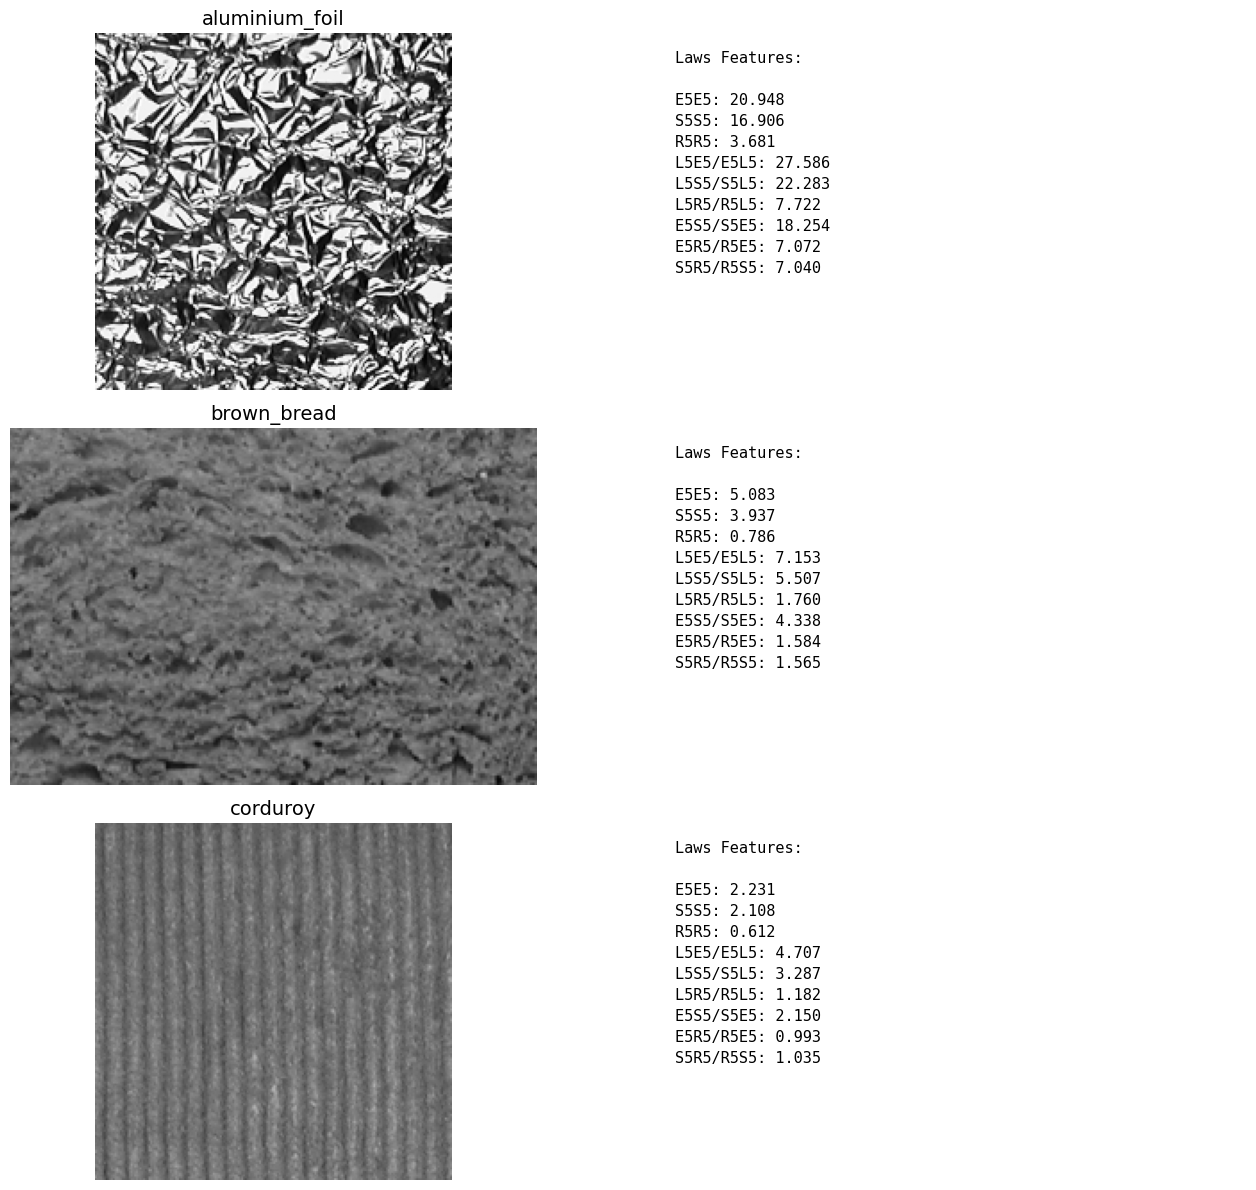

In [64]:
visualize_with_features(image_paths)

Рассчет текстурных характеристик на основе матрицы взаимной встречаемости GLCM:

In [66]:
def calculate_glcm_features(image):
    if image.dtype != np.uint8:
        image = image.astype(np.uint8)
    
    distances = [1]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    
    glcm = graycomatrix(image, distances=distances, angles=angles, 
                       levels=256, symmetric=True, normed=True)
    
    features = {}
    
    contrast = graycoprops(glcm, 'contrast')
    dissimilarity = graycoprops(glcm, 'dissimilarity')
    homogeneity = graycoprops(glcm, 'homogeneity')
    energy = graycoprops(glcm, 'energy')
    correlation = graycoprops(glcm, 'correlation')
    asm = graycoprops(glcm, 'ASM')
    
    features['contrast'] = np.mean(contrast)
    features['dissimilarity'] = np.mean(dissimilarity)
    features['homogeneity'] = np.mean(homogeneity)
    features['energy'] = np.mean(energy)
    features['correlation'] = np.mean(correlation)
    features['ASM'] = np.mean(asm)
    
    return features

In [69]:
def visualize_glcm_features(image_paths):
    n_images = len(image_paths)
    
    fig, axes = plt.subplots(n_images, 2, figsize=(14, 4 * n_images), 
                            gridspec_kw={'width_ratios': [1, 0.8]})
    
    if n_images == 1:
        axes = axes.reshape(1, -1)
    
    for idx, img_path in enumerate(image_paths):
        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is None:
                continue
            
            class_name = os.path.basename(os.path.dirname(img_path))
            
            features = calculate_glcm_features(img)
            
            axes[idx, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
            axes[idx, 0].set_title(f"{class_name}", fontsize=14)
            axes[idx, 0].axis('off')
            
            axes[idx, 1].axis('off')
            
            stats_text = "GLCM Features:\n\n"
            for name, value in features.items():
                formatted_value = f"{value:.3f}"
                stats_text += f"{name}: {formatted_value}\n"
            
            axes[idx, 1].text(0.1, 0.95, stats_text, 
                             fontsize=11, fontfamily='monospace',
                             verticalalignment='top',
                             linespacing=1.5)
                             
        except Exception:
            continue
    
    plt.tight_layout()
    plt.show()

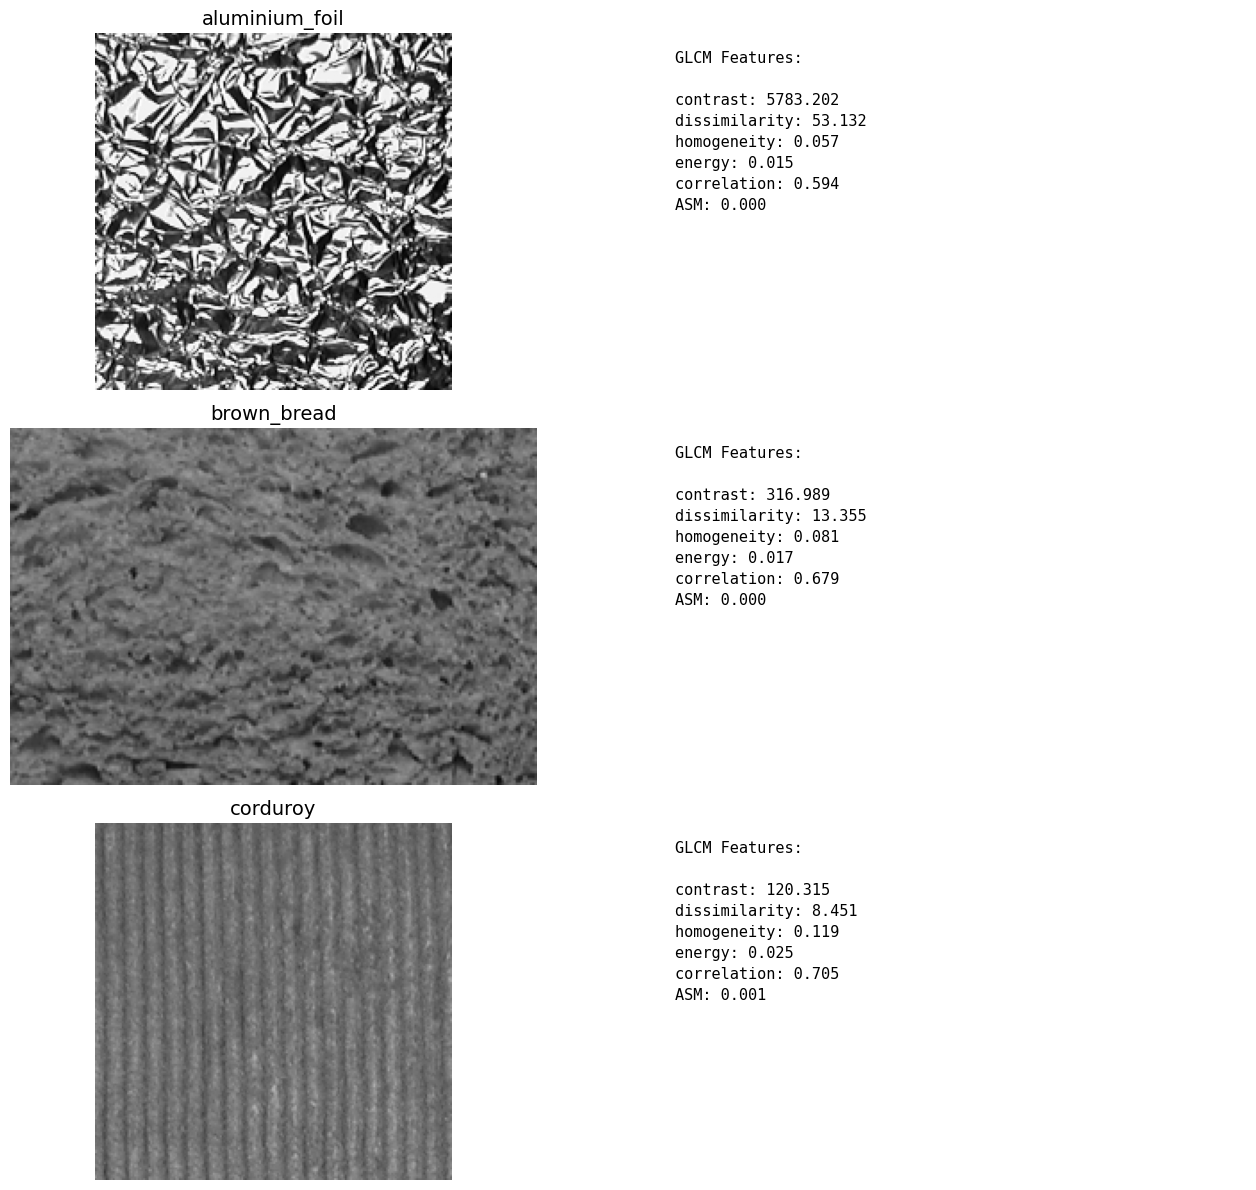

In [70]:
visualize_glcm_features(image_paths)

Тренировка классификатора (knn, svm, trees):

In [71]:
def getListOfFiles(dirName):
    listOfFile = os.listdir(dirName)
    allFiles = list()
    for entry in listOfFile:
        fullPath = os.path.join(dirName, entry)
        if os.path.isdir(fullPath):
            allFiles = allFiles + getListOfFiles(fullPath)
        else:
            allFiles.append(fullPath)
    return allFiles

In [80]:
def extract_features_from_dataset(img_paths):
    hist_features_collection = []
    laws_features_collection = []
    glcm_features_collection = []
    category_labels = []
    
    total_images = len(img_paths)
    
    for idx, img_file in enumerate(img_paths):
        if idx % 50 == 0:
            print(f"Загружено {idx}/{total_images} изображений")
        
        img_data = cv2.imread(img_file, cv2.IMREAD_GRAYSCALE)
        if img_data is None:
            continue
            
        img_resized = cv2.resize(img_data, (128, 128), interpolation=cv2.INTER_AREA)
        
        hist_result = calculate_histograms([img_file])
        if hist_result:
            hist_data = list(hist_result.values())[0]
            hist_features = [
                hist_data['mean'], hist_data['std'], hist_data['skewness'],
                hist_data['kurtosis'], hist_data['entropy'], hist_data['min'],
                hist_data['max'], hist_data['dominant_intensity'], 
                hist_data['contrast'], hist_data['total_pixels'] / 10000
            ]
        else:
            hist_features = [0] * 10
        
        laws_dict = calculate_laws_texture_energy(img_resized)
        laws_features = list(laws_dict.values())
        
        glcm_dict = calculate_glcm_features(img_resized)
        glcm_features = list(glcm_dict.values())
        
        hist_features_collection.append(hist_features)
        laws_features_collection.append(laws_features)
        glcm_features_collection.append(glcm_features)
        
        category_name = os.path.basename(os.path.dirname(img_file))
        category_labels.append(category_name)
    
    return (
        np.array(hist_features_collection),
        np.array(laws_features_collection),
        np.array(glcm_features_collection),
        np.array(category_labels)
    )

def train_classification_models():
    dataset_path = "./kth_tips_grey_200x200/KTH_TIPS"
    
    image_files = getListOfFiles(dataset_path)
    
    hist_data, laws_data, glcm_data, categories = extract_features_from_dataset(image_files)
    
    print(f"\nВсего изображений: {len(image_files)}")
    print(f"Гистограмма: {hist_data.shape}")
    print(f"Laws: {laws_data.shape}")
    print(f"GLCM: {glcm_data.shape}")
    print(f"Уникальных категорий: {len(np.unique(categories))}")
    
    label_encoder = LabelEncoder()
    encoded_labels = label_encoder.fit_transform(categories)
    
    feature_sets = {
        'Gistogram': hist_data,
        'Laws': laws_data,
        'GLCM': glcm_data
    }
    
    classifiers_config = {
        'kNN': KNeighborsClassifier(n_neighbors=3, n_jobs=-1),
        'SVM': SVC(kernel='rbf', random_state=42),
        'Tree': DecisionTreeClassifier(random_state=42, max_depth=10)
    }
    
    trained_classifiers = {}
    
    for feature_name, feature_matrix in feature_sets.items():
        print("\n")
        print(f"Классификация на основе {feature_name}")
        print("\n")
        
        X_train, X_test, y_train, y_test = train_test_split(
            feature_matrix, encoded_labels, test_size=0.25, 
            random_state=42, stratify=encoded_labels
        )
        
        normalizer = StandardScaler()
        X_train_norm = normalizer.fit_transform(X_train)
        X_test_norm = normalizer.transform(X_test)
        
        feature_classifiers = {}
        
        for clf_name, clf_template in classifiers_config.items():
            if clf_name == 'kNN':
                classifier = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
                classifier.fit(X_train, y_train)
                predictions = classifier.predict(X_test)
                feature_classifiers[clf_name] = classifier
                
            elif clf_name == 'SVM':
                classifier = SVC(kernel='rbf', random_state=42)
                classifier.fit(X_train_norm, y_train)
                predictions = classifier.predict(X_test_norm)
                feature_classifiers[clf_name] = (classifier, normalizer)
                
            elif clf_name == 'Tree':
                classifier = DecisionTreeClassifier(random_state=42, max_depth=10)
                classifier.fit(X_train, y_train)
                predictions = classifier.predict(X_test)
                feature_classifiers[clf_name] = classifier
            
            print(f"\n{classifier}:")
            print(classification_report(y_test, predictions, target_names=label_encoder.classes_))
        
        trained_classifiers[feature_name] = feature_classifiers
    
    best_models = {
        'Гистограмма_kNN': trained_classifiers['Gistogram']['kNN'],
        'Laws_Дерево': trained_classifiers['Laws']['Tree'],
        'Laws_SVM': trained_classifiers['Laws']['SVM']
    }
    
    return best_models

In [81]:
final_models = train_classification_models()

Загружено 0/811 изображений
Загружено 50/811 изображений
Загружено 100/811 изображений
Загружено 150/811 изображений
Загружено 200/811 изображений
Загружено 250/811 изображений
Загружено 300/811 изображений
Загружено 350/811 изображений
Загружено 400/811 изображений
Загружено 450/811 изображений
Загружено 500/811 изображений
Загружено 550/811 изображений
Загружено 600/811 изображений
Загружено 650/811 изображений
Загружено 700/811 изображений
Загружено 750/811 изображений
Загружено 800/811 изображений

Всего изображений: 811
Гистограмма: (810, 10)
Laws: (810, 9)
GLCM: (810, 6)
Уникальных категорий: 10


Классификация на основе Gistogram



KNeighborsClassifier(n_jobs=-1, n_neighbors=3):
                precision    recall  f1-score   support

aluminium_foil       0.95      0.95      0.95        20
   brown_bread       0.75      0.90      0.82        20
      corduroy       0.58      0.70      0.64        20
        cotton       0.44      0.52      0.48        21
       cracker       0.

Задача сегментации данных на основе классификации изображений каждым методом:

In [113]:
def segment_image_with_histogram_knn(image_path, model, block_size=16):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Не удалось загрузить {image_path}")
    
    h, w = img.shape
    seg_map = np.zeros((h, w), dtype=np.uint8)
    
    for i in range(0, h - block_size + 1, block_size):
        for j in range(0, w - block_size + 1, block_size):
            patch = img[i:i+block_size, j:j+block_size]
            
            hist_flat = cv2.calcHist([patch], [0], None, [256], [0, 256]).flatten()
            total_pixels = patch.size
            prob = hist_flat / total_pixels
            
            intensities = np.arange(256)
            mean_intensity = np.sum(intensities * prob)
            variance = np.sum(((intensities - mean_intensity) ** 2) * prob)
            std_intensity = np.sqrt(variance)
            
            if std_intensity > 0:
                skewness = np.sum(((intensities - mean_intensity) ** 3) * prob) / (std_intensity ** 3)
                kurt = np.sum(((intensities - mean_intensity) ** 4) * prob) / (std_intensity ** 4) - 3
            else:
                skewness = 0
                kurt = 0
            
            non_zero = np.where(hist_flat > 0)[0]
            min_intensity = non_zero[0] if len(non_zero) > 0 else 0
            max_intensity = non_zero[-1] if len(non_zero) > 0 else 255
            dominant_intensity = np.argmax(hist_flat)
            
            prob_nonzero = prob[prob > 0]
            entropy = -np.sum(prob_nonzero * np.log2(prob_nonzero)) if len(prob_nonzero) > 0 else 0
            
            contrast = max_intensity - min_intensity
            
            features = np.array([
                mean_intensity, std_intensity, skewness, kurt,
                entropy, min_intensity, max_intensity,
                dominant_intensity, contrast, total_pixels / 10000
            ]).reshape(1, -1)
            
            pred = model.predict(features)[0]
            seg_map[i:i+block_size, j:j+block_size] = pred
    
    return seg_map

In [114]:
def segment_image_with_laws(model_info, image_path, block_size=16):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Не удалось загрузить {image_path}")
    
    h, w = img.shape
    seg_map = np.zeros((h, w), dtype=np.uint8)
    
    is_svm = isinstance(model_info, tuple)
    if is_svm:
        model, scaler = model_info
    else:
        model = model_info
        scaler = None
    
    for i in range(0, h - block_size + 1, block_size):
        for j in range(0, w - block_size + 1, block_size):
            patch = img[i:i+block_size, j:j+block_size]
            
            laws_feat_dict = calculate_laws_texture_energy(patch.astype(np.float32))
            laws_feat = np.array(list(laws_feat_dict.values())).reshape(1, -1)
            
            if scaler is not None:
                laws_feat = scaler.transform(laws_feat)
            
            pred = model.predict(laws_feat)[0]
            seg_map[i:i+block_size, j:j+block_size] = pred
    
    return seg_map

Сегментация: Гистограмма + kNN
Сегментация: Laws + Tree
Сегментация: Laws + SVM


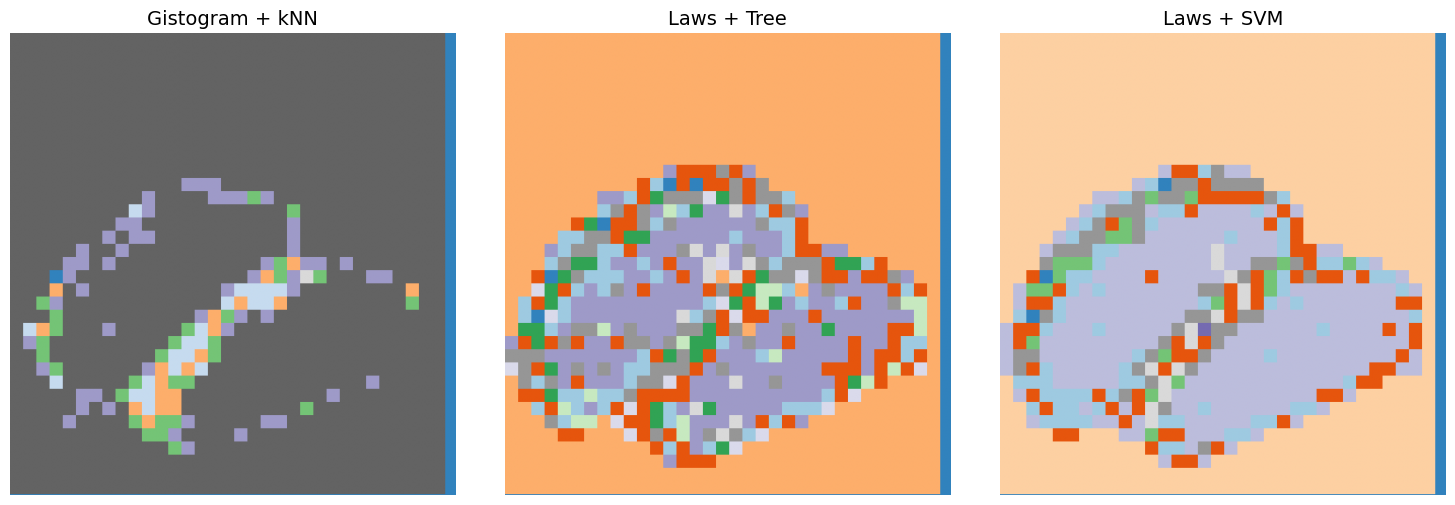

In [115]:
image_path = "image10.jpg"

print("Сегментация: Гистограмма + kNN")
seg1 = segment_image_with_histogram_knn(image_path, final_models['Гистограмма_kNN'], block_size=16)

print("Сегментация: Laws + Tree")
seg2 = segment_image_with_laws(final_models['Laws_Дерево'], image_path, block_size=16)

print("Сегментация: Laws + SVM")
seg3 = segment_image_with_laws(final_models['Laws_SVM'], image_path, block_size=16)

def normalize_labels(seg):
    unique_labels = np.unique(seg)
    if len(unique_labels) == 0:
        return seg.astype(np.uint8)
    mapping = {label: idx for idx, label in enumerate(unique_labels)}
    normalized = np.vectorize(mapping.get)(seg)
    if len(unique_labels) > 1:
        normalized = (normalized * (255 / (len(unique_labels) - 1))).astype(np.uint8)
    else:
        normalized = normalized.astype(np.uint8)
    return normalized

out1 = normalize_labels(seg1)
out2 = normalize_labels(seg2)
out3 = normalize_labels(seg3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(out1, cmap='tab20c')
axes[0].set_title("Gistogram + kNN", fontsize=14)
axes[0].axis('off')

axes[1].imshow(out2, cmap='tab20c')
axes[1].set_title("Laws + Tree", fontsize=14)
axes[1].axis('off')

axes[2].imshow(out3, cmap='tab20c')
axes[2].set_title("Laws + SVM", fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()
    

Ручная разметка изображений на регионы:

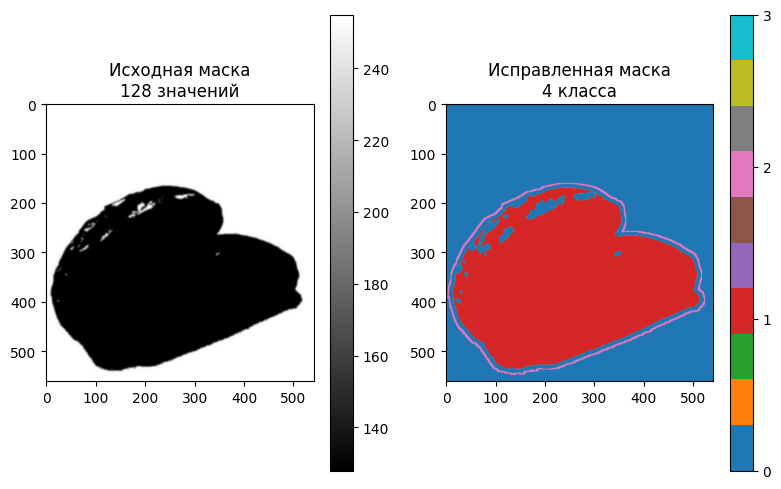

In [145]:
n_colors = 4

image_path = "image10.jpg"

img = Image.open(image_path).convert('L')

img_array = np.array(img)
threshold = 240
is_foreground = img_array < threshold

visual_mask_full = np.where(is_foreground, 128, 255).astype(np.uint8)

from scipy.ndimage import gaussian_filter

noisy_mask = gaussian_filter(visual_mask_full.astype(float), sigma=1.5)

noisy_mask = np.clip(noisy_mask, 0, 255).astype(np.uint8)

original_mask = noisy_mask

def keep_top_colors(mask, n_colors=4):
    unique, counts = np.unique(mask, return_counts=True)
    sorted_indices = np.argsort(-counts)
    top_colors = unique[sorted_indices[:n_colors]]
    
    result = np.zeros_like(mask)
    for new_value, old_value in enumerate(top_colors):
        result[mask == old_value] = new_value
    
    return result

# исправленная маска
fixed_manual_mask = keep_top_colors(original_mask, n_colors=4)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_mask, cmap='gray')
plt.title(f'Исходная маска\n{len(np.unique(original_mask))} значений')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(fixed_manual_mask, cmap='tab10')
plt.title(f'Исправленная маска\n{n_colors} класса')
plt.colorbar(ticks=np.arange(n_colors))

plt.tight_layout()
plt.show()


Сравнение результата полученной классификации и размеченной:

In [ ]:
from scipy.optimize import linear_sum_assignment

def calculate_accuracy_with_optimal_mapping(pred_mask, true_mask):
    unique_pred = np.unique(pred_mask)
    unique_true = np.unique(true_mask)
    
    n_pred = len(unique_pred)
    n_true = len(unique_true)
    
    # матрица совпадений
    confusion_matrix = np.zeros((n_pred, n_true), dtype=int)
    
    for i, p_val in enumerate(unique_pred):
        for j, t_val in enumerate(unique_true):
            mask = (pred_mask == p_val) & (true_mask == t_val)
            confusion_matrix[i, j] = np.sum(mask)
    
    row_ind, col_ind = linear_sum_assignment(-confusion_matrix)
    
    max_matches = np.sum(confusion_matrix[row_ind, col_ind])
    total_pixels = pred_mask.size
    
    accuracy_percent = (max_matches / total_pixels) * 100.0
    
    return accuracy_percent, confusion_matrix, row_ind, col_ind

In [144]:
methods = [
    ("Gistogram + kNN", seg1),
    ("Laws + Tree", seg2),
    ("Laws + SVM", seg3)
]

results = {}

for name, pred_mask in methods:
    acc, cm, row_ind, col_ind = calculate_accuracy_with_optimal_mapping(pred_mask, fixed_manual_mask)
    results[name] = acc
    print(f"{name}: {acc:.2f}% совпадений")


Gistogram + kNN: 60.31% совпадений
Laws + Tree: 67.13% совпадений
Laws + SVM: 73.14% совпадений
